# 3.1. Получаем границы доменов из Hi-C

Возвращаемся к анализу hic. Берем карту в формате `mcool`, считаем инсуляцию и сохраняем границы доменов в bedGraph

Эти файлы нужны для 3го блокнота, где мы сравним границы доменов с CTCF ChiPseq

**Входные файлы:**

- `../day2_HiC_practice/data/MoPh7_enr_v2.mcool`

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import cooler
import cooltools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cooltools import insulation

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 11

### Пути и параметры

Берем разрешение 10Kb, чтобы точнее определить границу. Размер окна задает масштаб границ, dimond score здесь используем 300 kb, как в блокноте второго дня

In [15]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sample = "MoPh7_enr_v2"
resolution = 10_000
window = 300_000
windows = [window]

cool_path = ROOT / f"../day2_HiC_practice/data/{sample}.mcool"
cool_uri = f"{cool_path}::/resolutions/{resolution}"

boundaries_bed = ROOT / "data/boundaries/MoPh7_boundaries.bed"
boundaries_bedgraph = ROOT / "data/boundaries/MoPh7_boundaries.bedGraph"
insulation_table_path = ROOT / "results/tables/MoPh7_insulation_table.tsv.gz"

In [16]:
clr = cooler.Cooler(cool_uri)

if "weight" not in clr.bins().columns:
    raise ValueError("В cooler нет balance weight. Сначала нужно сделать cooler balance.")

clr.chromsizes.head()

name
1    248387328
2    242696752
3    201105948
4    193574945
5    182045439
Name: length, dtype: int32

### Оставляем основные человеческие хромосомы

В нашей hic карте хромосомы называются без `chr`, поэтому здесь используем `1`, `2`, ..., `X`, `Y`.

In [17]:
canonical_chroms = [str(i) for i in range(1, 23)] + ["X", "Y"]

chromsizes = clr.chromsizes.reset_index()
chromsizes.columns = ["chrom", "length"]
chromsizes = chromsizes[chromsizes["chrom"].isin(canonical_chroms)].copy()

view_df = pd.DataFrame({
    "chrom": chromsizes["chrom"],
    "start": 0,
    "end": chromsizes["length"],
    "name": chromsizes["chrom"],
})

view_df.head()

,chrom,start,end,name
0,1,0,248387328,1
1,2,0,242696752,2
2,3,0,201105948,3
3,4,0,193574945,4
4,5,0,182045439,5


### Считаем insulation значение

`cooltools.insulation` возвращает таблицу по геномным бинам. В ней есть:

- `log2_insulation_значение_WINDOW`
- `boundary_strength_WINDOW`
- `is_boundary_WINDOW`

In [18]:
insulation_table = insulation(
    clr,
    windows,
    view_df=view_df,
    clr_weight_name="weight",
    nproc=4,
)

insulation_table.head()

INFO:root:creating a Pool of 4 workers


,chrom,start,end,region,is_bad_bin,log2_insulation_score_300000,n_valid_pixels_300000,boundary_strength_300000,is_boundary_300000
0,1,0,10000,1,True,NaN,0.0,NaN,False
1,1,10000,20000,1,True,NaN,0.0,NaN,False
2,1,20000,30000,1,True,NaN,0.0,NaN,False
3,1,30000,40000,1,True,NaN,0.0,NaN,False
4,1,40000,50000,1,True,NaN,0.0,NaN,False


In [19]:
score_col = f"log2_insulation_score_{window}"
strength_col = f"boundary_strength_{window}"
is_boundary_col = f"is_boundary_{window}"

boundary_rows = insulation_table[
    insulation_table[is_boundary_col].fillna(False)
].copy()

boundary_rows["center"] = ((boundary_rows["start"] + boundary_rows["end"]) / 2).astype(int)
boundary_rows["chrom_chr"] = "chr" + boundary_rows["chrom"].astype(str)

print("Number of boundaries:", len(boundary_rows))
boundary_rows[["chrom", "start", "end", "center", strength_col]].head()

Number of boundaries: 4893


,chrom,start,end,center,boundary_strength_300000
74,1,740000,750000,745000,0.697147
107,1,1070000,1080000,1075000,1.097929
136,1,1360000,1370000,1365000,0.489446
184,1,1840000,1850000,1845000,0.473751
217,1,2170000,2180000,2175000,0.786446


### Сохраняем BED и bedGraph

Для следующего блокнота сохраняем координаты с `chr`-префиксом, потому что CTCF `bw` и пики из третьего дня тоже используют `chr1`, `chr2` и так далее.

In [ ]:
boundaries_bed.parent.mkdir(parents=True, exist_ok=True)
insulation_table_path.parent.mkdir(parents=True, exist_ok=True)

bed = pd.DataFrame({
    "chrom": boundary_rows["chrom_chr"],
    "start": boundary_rows["start"].astype(int),
    "end": boundary_rows["end"].astype(int),
    "name": [f"boundary_{i}" for i in range(len(boundary_rows))],
    "score": boundary_rows[strength_col].fillna(0),
})

bed.to_csv(boundaries_bed, sep="\t", header=False, index=False)

bedgraph = bed[["chrom", "start", "end", "score"]].copy()
bedgraph.to_csv(boundaries_bedgraph, sep="\t", header=False, index=False)

# Таблицу можно не сохранять
# insulation_table.to_csv(insulation_table_path, sep="\t", index=False, compression="gzip")

print("Saved:", boundaries_bed)
print("Saved:", boundaries_bedgraph)
# print("Saved:", insulation_table_path)

Saved: /data/ddpanchenko/main_dom/OMICS_course_spring_2026/day5_omics_practice/data/boundaries/MoPh7_boundaries.bed
Saved: /data/ddpanchenko/main_dom/OMICS_course_spring_2026/day5_omics_practice/data/boundaries/MoPh7_boundaries.bedGraph
Saved: /data/ddpanchenko/main_dom/OMICS_course_spring_2026/day5_omics_practice/results/tables/MoPh7_insulation_table.tsv.gz


### Быстрая проверка

Посмотрим распределение силы границ.

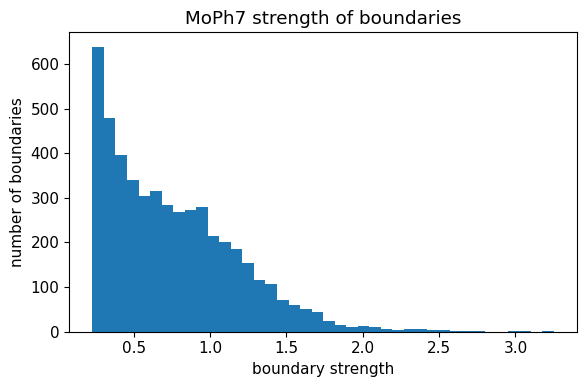

In [21]:
plt.figure(figsize=(6, 4))
plt.hist(bed["score"], bins=40)
plt.title("MoPh7 strength of boundaries")
plt.xlabel("boundary strength")
plt.ylabel("number of boundaries")
plt.tight_layout()
plt.show()